**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---
Clase 4 - Funciones económicas - Puntos de equilibrio - Sistemas de ecuaciones

✅ Ya experimentamos representar y graficar funciones

✅ También vimos funciones económicas

✅ Ahora repasemos las funciones de oferta y demanda para poder resolver sistemas, hallar el equilibrio de mercado y analizar sus variantes!!!



---

- Función de demanda: relaciona la cantidad demandada y el precio del mercado. `x = D(p), donde x representa la cantidad que los consumidores están dispuestos a adquirir para distintos niveles o valores del precio p.`

- Función de oferta: relaciona cantidad ofrecida y el precio. `x = Of (p), estableciendo las
cantidades x del bien considerado que los productores ofrecen para cada valor del precio.`

 Si las funciones de demanda u oferta están expresadas en función del precio p, habrá que hallar la función inversa.

---

Punto de Equilibrio de mercado:

Se produce equilibrio de mercado cuando la cantidad demandada de un producto es igual a la cantidad ofrecida del mismo.
El precio y la cantidad de equilibrio corresponden a las coordenadas del punto de intersección de las curvas de la oferta y la demanda.

Para determinar analíticamente el punto de equilibrio debe resolverse el sistema de ecuaciones que representan las funciones de oferta y de demanda.

---



✅ Paso 1 - Importamos las librerías que vamos a usar

In [98]:
import numpy as np                 #Para hacer operaciones matemáticas
import matplotlib.pyplot as plt    #Para hacer gráficos
import sympy as sp                 #Para hacer ecuaciones con variables simbólicas
from matplotlib.ticker import MultipleLocator

In [99]:
# Variables
layout = 'constrained'
figsize = (12,6)



---

⏩ Dado el siguiente sistema:

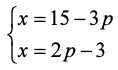

i) Determinar cuál ecuación representa una curva de demanda y cuál una de oferta.

ii) Determinar analítica y gráficamente el precio de equilibrio en el mercado.

---



In [100]:
#Paso 1
#Armamos las funciones inversas

# p = -1/3x + 5      Curva de demanda ( tiene pendiente negativa )
# p = 1/2x + 3/2     Curva de oferta ( tiene pendiente positiva )

# Generamos las funciones
# Estas funciones trabajan tanto con números como con símbolos de SymPy

def demanda(x):
    """Función de demanda inversa: p = -1/3*x + 5"""
    return -x/3 + 5

def oferta(x):
    """Función de oferta inversa: p = 1/2*x + 3/2"""
    return x/2 + 3/2


In [101]:
#Paso 2
#Resolvemos el sistema para hallar el punto de equilibrio

# Definimos las variables simbólicas
x, p = sp.symbols('x p')

# Definimos las ecuaciones
eq1 = sp.Eq(p, demanda(x))
eq2 = sp.Eq(p, oferta(x))

# Resolvemos el sistema
solucion = sp.solve((eq1, eq2), (x, p))
x_eq = solucion[x]
p_eq = solucion[p]

print('solucion:', solucion)
print(f"Solución: El punto de equilibrio es,  x_eq = {x_eq:.2f}, p_eq = {p_eq:.2f}")


solucion: {p: 3.60000000000000, x: 4.20000000000000}
Solución: El punto de equilibrio es,  x_eq = 4.20, p_eq = 3.60


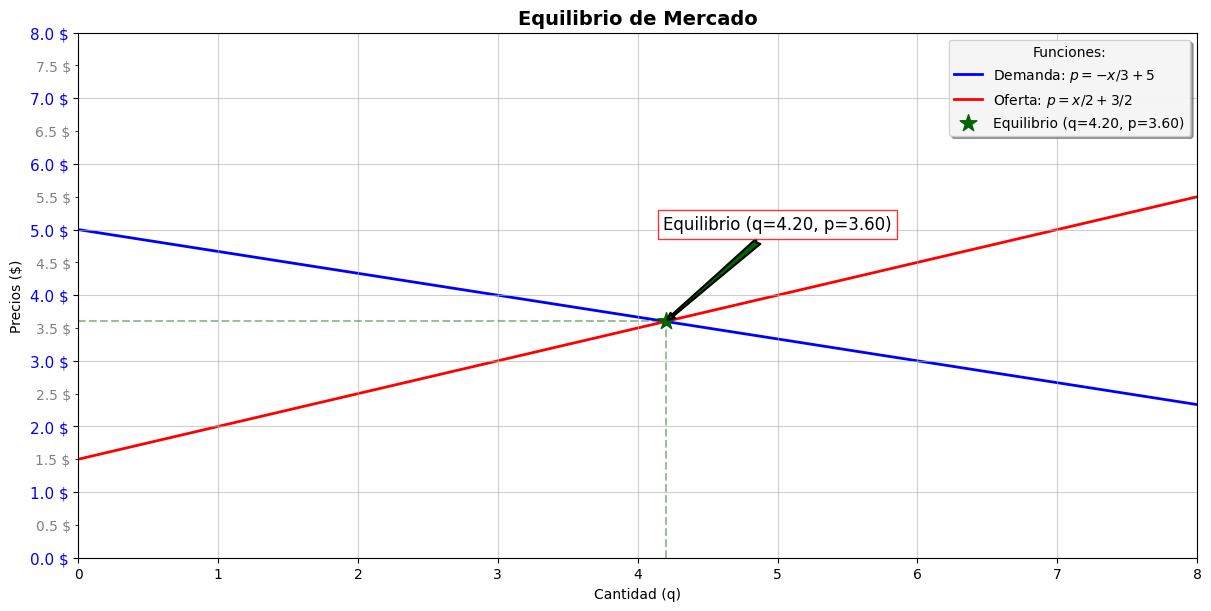

In [ ]:
#Paso 3
# Visualización

fig, ax = plt.subplots(figsize=figsize, layout=layout)

# Establezco el dominio o escala del eje x
min_y = 0
max_y = 8
min_x = 0
max_x = 8

q_eq = solucion[x]
p_eq = solucion[p]

X = np.linspace(min_x, max_x, 100)

colors = ['blue', 'red', 'brown', 'purple']

# Grafico múltiples series
graficas = [
    {
        'data': demanda(X),
        'label':'Demanda: $p = -x/3 + 5$',
    },
    {
        'data':  oferta(X),
        'label': 'Oferta: $p = x/2 + 3/2$',
    },
]
label_equilibrio = f'Equilibrio (q={q_eq:.2f}, p={p_eq:.2f})'

#Grafico las funciones
for i, grafica in enumerate(graficas):
    ax.plot(X,
            grafica['data'],
            linewidth=2,
            color=colors[i],
            label=grafica['label'],
            zorder = 1
            )

# Grafico los puntos y líneas de equilibrio
colors_eq = ['darkgreen', '#580f41', 'chocolate']

scatters = [
    {
        'x': q_eq,
        'y': p_eq,
        'marker': '*',
        'label': label_equilibrio,
        'xtext': 5,
        'ytext': 5
    }
]

for i, scatter in enumerate(scatters):
    # Puntos de equilibrio
    ax.scatter(scatter['x'],
                scatter['y'],
                marker=scatter['marker'],
                color=colors_eq[i],
                s=160, # tamaño en pixeles
                label=scatter['label'],
                zorder = 2
                )
    
    # Líneas al punto de equilibrio
    ax.vlines(x=scatter['x'],
        ymin=0,
        ymax=scatter['y'],
        linestyles="--",
        color=colors_eq[i],
        alpha=0.4
        )
    ax.hlines(y=scatter['y'],
        xmin=0,
        xmax=scatter['x'],
        linestyles="--",
        color=colors_eq[i],
        alpha=0.4
        )
    
    # Anotación con flecha fancy
    ax.annotate(
        text=scatter['label'],
        xy=(scatter['x'], scatter['y']),
        xytext=(scatter['xtext'], scatter['ytext']),
        fontsize=12,
        ha='center',
        arrowprops=dict(
            arrowstyle='fancy',
            facecolor=colors_eq[i],
            edgecolor='black',
            linewidth=1.5
        ),
        bbox=dict(facecolor='white', edgecolor='red', alpha=0.8)
    )

# DETALLES DEL GRÁFICO

# Configurar ticks mayores
major_ticks = 1
minor_ticks = major_ticks / 2

# Etiquetas de Ejes
ax.set_ylabel('Precios ($)')
ax.set_xlabel('Cantidad (q)')

# Escala de Ejes
ax.set_ylim(min_y, max_y)
ax.set_yticks(np.arange(min_y, max_y, major_ticks))
ax.set_xlim(min_x, max_x)

# TICKS MAYORES EJE Y:
ax.yaxis.set_major_locator(MultipleLocator(major_ticks))
ax.yaxis.set_major_formatter('{x:.1f} $')
ax.tick_params(axis='y', which='major', labelsize=11, labelcolor='blue')

# TICKS MENORES EJE Y:
ax.yaxis.set_minor_locator(MultipleLocator(minor_ticks))
ax.yaxis.set_minor_formatter('{x:.1f} $')
ax.tick_params(axis='y', which='minor', labelsize=10, labelcolor='gray')

# TICKS EJE X
# ax.tick_params(axis='x', labelsize=11) # labelrotation=25,

ax.set_title(
    'Equilibrio de Mercado',
    fontsize=14,
    fontweight='bold'
    )
ax.legend(
    loc='best',
    shadow=True,
    fancybox=True,
    framealpha=0.9,
    title='Funciones:',
    #ncols=4
    )

ax.grid(True, alpha=0.6)
plt.show()

In [103]:
#Paso 3
# Graficamos

""" plt.figure(figsize=(8, 6))

#establecemos el rango de x
valores_x = np.linspace(0, 10, 100) # Dominio de la función, eje de las abcisas "x"

#graficamos las curvas
plt.plot(valores_x,
    demanda(valores_x),
    'blue',
    label='Demanda: $p = -1/3*x + 5$' # Se colocan entre símbolo $ para que muestre la fórmula
    )
plt.plot(valores_x,
    oferta(valores_x),
    'red',
    label='Oferta: $p = 1/2*x + 3/2$'
    )

#Agregamos los detalles del gráfico
plt.scatter(x_eq,
            p_eq,
            color='green',
            s=100, # tamaño en pixeles
            label=f'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})'
            )

plt.ylabel('Precio (p)')
plt.xlabel('Cantidad (x)')
plt.legend()
plt.grid(True)
plt.title('Equilibrio de Mercado ')
plt.show() """

' plt.figure(figsize=(8, 6))\n\n#establecemos el rango de x\nvalores_x = np.linspace(0, 10, 100) # Dominio de la función, eje de las abcisas "x"\n\n#graficamos las curvas\nplt.plot(valores_x,\n    demanda(valores_x),\n    \'blue\',\n    label=\'Demanda: $p = -1/3*x + 5$\' # Se colocan entre símbolo $ para que muestre la fórmula\n    )\nplt.plot(valores_x,\n    oferta(valores_x),\n    \'red\',\n    label=\'Oferta: $p = 1/2*x + 3/2$\'\n    )\n\n#Agregamos los detalles del gráfico\nplt.scatter(x_eq,\n            p_eq,\n            color=\'green\',\n            s=100, # tamaño en pixeles\n            label=f\'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})\'\n            )\n\nplt.ylabel(\'Precio (p)\')\nplt.xlabel(\'Cantidad (x)\')\nplt.legend()\nplt.grid(True)\nplt.title(\'Equilibrio de Mercado \')\nplt.show() '

✅ Ahora supongamos dos situaciones :

a) Se agrega un impuesto al productor t=1

b) Se otorga un subsidio de s=0,8 a los productores

¿Cómo varía la oferta?¿Qué sucede con el precio de equilibrio?

---





In [104]:
#Paso 1
#Planteamos las funciones de oferta nuevas:

def oferta_impuesto(x):
  return 1/2*x + 3/2+1

def oferta_subsidio(x):
  return 1/2*x + 3/2-0.8

In [105]:
#Paso 2
#Resolvemos el sistema para hallar el punto de equilibrio en el caso del impuesto

# Definimos las variables simbólicas
x, p = sp.symbols('x p')

# Definimos las ecuaciones
eq1 = sp.Eq(p, -(1/3)* x + 5)
eq3 = sp.Eq(p, oferta_impuesto(x)) #oferta con impuesto
eq4 = sp.Eq(p, oferta_subsidio(x)) #oferta con subsidio

# Resolvemos los sistemas
solucion_impuesto_prod = sp.solve((eq1, eq3), (x, p))
x_eq_imp = solucion_impuesto_prod[x]
p_eq_imp = solucion_impuesto_prod[p]


solucion_subsidio_prod = sp.solve((eq1, eq4), (x, p))
x_eq_sub = solucion_subsidio_prod[x]
p_eq_sub = solucion_subsidio_prod[p]

print(f"Solución: El punto de equilibrio al agregar un impuesto al productor de t=1 es,  x_eq_imp = {x_eq_imp:.2f}, p_eq_imp = {p_eq_imp:.2f}")
print(f"Solución: El punto de equilibrio al otorgar un subsidio al productor de s=0,8 es,  x_eq_sub = {x_eq_sub:.2f}, p_eq_sub = {p_eq_sub:.2f}")

Solución: El punto de equilibrio al agregar un impuesto al productor de t=1 es,  x_eq_imp = 3.00, p_eq_imp = 4.00
Solución: El punto de equilibrio al otorgar un subsidio al productor de s=0,8 es,  x_eq_sub = 5.16, p_eq_sub = 3.28


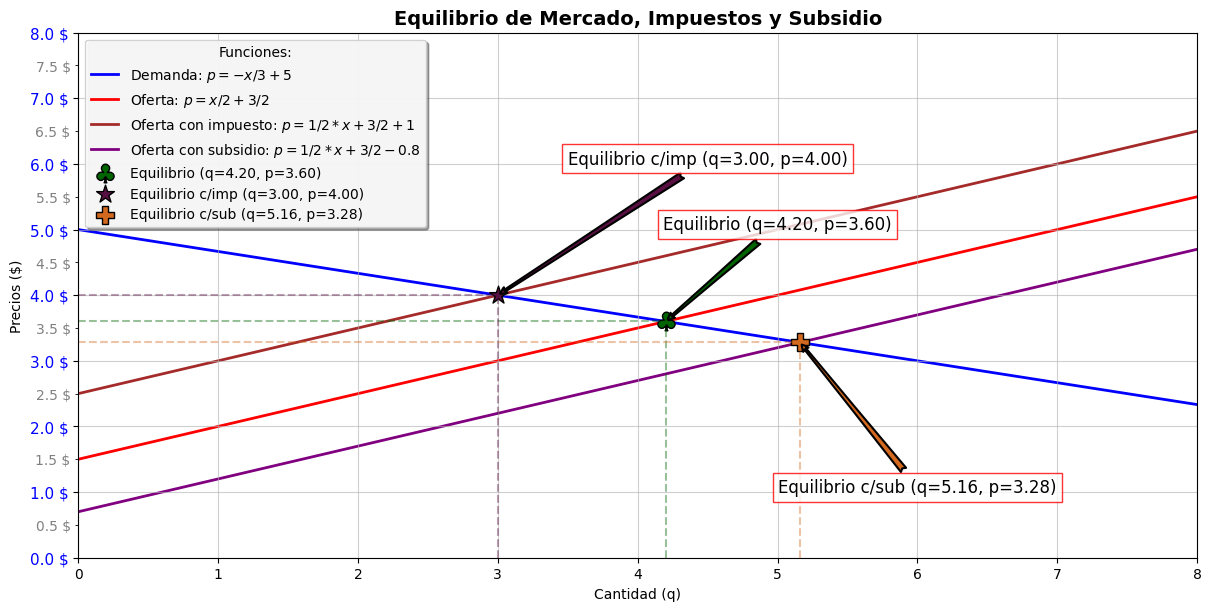

In [ ]:
#Paso 3
# Visualización

fig, ax = plt.subplots(figsize=figsize, layout=layout)

# Establezco el dominio o escala del eje x
min_y = 0
max_y = 8
min_x = 0
max_x = 8

q_eq = x_eq # optimos*
p_eq = p_eq # optimos*

q_eq_imp = x_eq_imp
p_eq_imp = p_eq_imp

q_eq_sub = x_eq_sub
p_eq_sub = p_eq_sub

X = np.linspace(min_x, max_x, 100)

colors = ['blue', 'red', 'brown', 'purple']

# Grafico múltiples series
graficas = [
    {
        'data': demanda(X),
        'label':'Demanda: $p = -x/3 + 5$',
    },
    {
        'data':  oferta(X),
        'label': 'Oferta: $p = x/2 + 3/2$',
    },
    {
        'data': oferta_impuesto(X),
        'label':'Oferta con impuesto: $p = 1/2*x + 3/2+1$',
    },
    {
        'data':  oferta_subsidio(X),
        'label': 'Oferta con subsidio: $p = 1/2*x + 3/2-0.8$',
    }
]

#Grafico las funciones
label_equilibrio = f'Equilibrio (q={q_eq:.2f}, p={p_eq:.2f})'

for i, grafica in enumerate(graficas):
    ax.plot(X,
            grafica['data'],
            linewidth=2,
            color=colors[i],
            label=grafica['label'],
            zorder = 1
            )

# Grafico los puntos y líneas de equilibrio
colors_eq = ['darkgreen', '#580f41', 'chocolate']

scatters = [
    {
        'x': q_eq,
        'y': p_eq,
        'marker': r"$\clubsuit$",
        'label': label_equilibrio,
        'xtext': 5,
        'ytext': 5
    },
    {
        'x': q_eq_imp,
        'y': p_eq_imp,
        'marker': '*',
        'label': f'Equilibrio c/imp (q={q_eq_imp:.2f}, p={p_eq_imp:.2f})',
        'xtext': 4.5,
        'ytext': 6
    },
    {
        'x': q_eq_sub,
        'y': p_eq_sub,
        'marker': 'P',
        'label': f'Equilibrio c/sub (q={q_eq_sub:.2f}, p={p_eq_sub:.2f})',
        'xtext': 6,
        'ytext': 1
    },
]

for i, scatter in enumerate(scatters):
    # Puntos de equilibrio
    ax.scatter(scatter['x'],
                scatter['y'],
                marker=scatter['marker'],
                color=colors_eq[i],
                s=180, # tamaño en pixeles
                label=scatter['label'],
                zorder = 2,
                edgecolor='black',
                )
    
    # Líneas al punto de equilibrio
    ax.vlines(x=scatter['x'],
        ymin=0,
        ymax=scatter['y'],
        linestyles="--",
        color=colors_eq[i],
        alpha=0.4
        )
    ax.hlines(y=scatter['y'],
        xmin=0,
        xmax=scatter['x'],
        linestyles="--",
        color=colors_eq[i],
        alpha=0.4
        )
    
    # Anotación con flecha fancy
    ax.annotate(
        text=scatter['label'],
        xy=(scatter['x'], scatter['y']),
        xytext=(scatter['xtext'], scatter['ytext']),
        fontsize=12,
        ha='center',
        arrowprops=dict(
            arrowstyle='fancy',
            facecolor=colors_eq[i],
            edgecolor='black',
            linewidth=1.5
        ),
        bbox=dict(facecolor='white', edgecolor='red', alpha=0.8)
    )

# Agrego detalles del gráfico
# Configurar ticks mayores
major_ticks = 1
minor_ticks = major_ticks / 2

# Etiquetas de Ejes
ax.set_ylabel('Precios ($)')
ax.set_xlabel('Cantidad (q)')

# Escala de Ejes
ax.set_ylim(min_y, max_y)
ax.set_yticks(np.arange(min_y, max_y, major_ticks))
ax.set_xlim(min_x, max_x)

# TICKS MAYORES EJE Y:
ax.yaxis.set_major_locator(MultipleLocator(major_ticks))
ax.yaxis.set_major_formatter('{x:.1f} $')
ax.tick_params(axis='y', which='major', labelsize=11, labelcolor='blue')

# TICKS MENORES EJE Y:
ax.yaxis.set_minor_locator(MultipleLocator(minor_ticks))
ax.yaxis.set_minor_formatter('{x:.1f} $')
ax.tick_params(axis='y', which='minor', labelsize=10, labelcolor='gray')

# TICKS EJE X
# ax.tick_params(axis='x', labelsize=11) # labelrotation=25,

ax.set_title(
    'Equilibrio de Mercado, Impuestos y Subsidio',
    fontsize=14,
    fontweight='bold'
    )
ax.legend(
    loc='best',
    shadow=True,
    fancybox=True,
    framealpha=0.9,
    title='Funciones:',
    #ncols=4
    )

ax.grid(True, alpha=0.6)
plt.show()

In [ ]:
#Paso 3
# Graficamos los efectos
""" 
plt.figure(figsize=(10, 10))

#establecemos el rango de x
valores_x = np.linspace(0, 10, 100)

#graficamos las curvas
plt.plot(valores_x, demanda(valores_x) , 'blue', label='Demanda: $p = -1/3*x + 5$')
plt.plot(valores_x, oferta(valores_x) , 'red', label='Oferta: $p = 1/2*x + 3/2$')
plt.plot(valores_x, oferta_impuesto(valores_x) , 'green', label='Oferta con impuesto: $p = 1/2*x + 3/2+1$')
plt.plot(valores_x, oferta_subsidio(valores_x) , 'orange', label='Oferta con subsidio: $p = 1/2*x + 3/2-0.8$')

#Agregamos los detalles del gráfico
plt.scatter(x_eq, p_eq, color='red', s=100, label=f'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})')
plt.scatter(x_eq_imp, p_eq_imp, color='green', s=100, label=f'Equilibrio c/imp (x={x_eq_imp:.2f}, p={p_eq_imp:.2f})')
plt.scatter(x_eq_sub, p_eq_sub, color='orange', s=100, label=f'Equilibrio c/sub (x={x_eq_sub:.2f}, p={p_eq_sub:.2f})')
plt.ylabel('Precio (p)')
plt.xlabel('Cantidad (x)')
plt.legend()
plt.grid(True)
plt.title('Equilibrio de Mercado y los efectos de impuestos vs subsidios a la producción')
plt.show() """

" \nplt.figure(figsize=(10, 10))\n\n#establecemos el rango de x\nvalores_x = np.linspace(0, 10, 100)\n\n#graficamos las curvas\nplt.plot(valores_x, demanda(valores_x) , 'blue', label='Demanda: $p = -1/3*x + 5$')\nplt.plot(valores_x, oferta(valores_x) , 'red', label='Oferta: $p = 1/2*x + 3/2$')\nplt.plot(valores_x, oferta_impuesto(valores_x) , 'green', label='Oferta con impuesto: $p = 1/2*x + 3/2+1$')\nplt.plot(valores_x, oferta_subsidio(valores_x) , 'orange', label='Oferta con subsidio: $p = 1/2*x + 3/2-0.8$')\n\n#Agregamos los detalles del gráfico\nplt.scatter(x_eq, p_eq, color='red', s=100, label=f'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})')\nplt.scatter(x_eq_imp, p_eq_imp, color='green', s=100, label=f'Equilibrio c/imp (x={x_eq_imp:.2f}, p={p_eq_imp:.2f})')\nplt.scatter(x_eq_sub, p_eq_sub, color='orange', s=100, label=f'Equilibrio c/sub (x={x_eq_sub:.2f}, p={p_eq_sub:.2f})')\nplt.ylabel('Precio (p)')\nplt.xlabel('Cantidad (x)')\nplt.legend()\nplt.grid(True)\nplt.title('Equilibrio de M

✅ Los impuestos y subsidios alteran el equilibrio de mercado al modificar los incentivos económicos de productores y consumidores.

✅ Con un impuesto específico (como $1 por unidad), la curva de oferta se desplaza hacia la izquierda, ya que los productores requieren un precio mayor para cubrir el costo adicional. Esto genera:

Un aumento del precio pagado por los consumidores (de 3.6 a 4),

Una reducción del precio recibido por los productores (de 3.6 a 3 tras descontar el impuesto),

Una disminución de la cantidad transada (de 4.2 a 3 unidades), creando una pérdida social por la reducción de intercambios mutuamente beneficiosos.

✅ Con un subsidio (como $0.8 por unidad), la curva de oferta se desplaza hacia la derecha, ya que los productores están dispuestos a aceptar un precio menor debido al apoyo estatal. Esto provoca:

Una reducción del precio pagado por los consumidores (de 3.6 a 3.28),

Un aumento del precio efectivo para productores (de 3.6 a 4.2, incluyendo el subsidio),

Un incremento de la cantidad transada (de 4.2 a 5.16 unidades), incentivando una producción excesiva.



---


⏩ Dado el siguiente sistema:

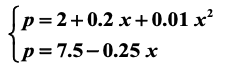

i) Determinar cuál ecuación representa una curva de demanda y cuál una de oferta.

ii) Determinar analítica y gráficamente el precio de equilibrio en el mercado.

---



In [ ]:
#Paso 1

#Generamos las funciones

def demanda_2(x):
  return 7.5-0.25*x

def oferta_2(x):
  return 2+0.2 * x +0.01*x**2

In [ ]:
#Paso 2
#Resolvemos el sistema para hallar el punto de equilibrio

# Definimos las variables simbólicas
x, p = sp.symbols('x p')

# Definimos las ecuaciones
eq1 = sp.Eq(p, 7.5-0.25*x)
eq2 = sp.Eq(p, 2+0.2 * x +0.01*x**2)

# Resolvemos el sistema
solucion = sp.solve((eq1, eq2), (x, p))
print(f"Soluciones posibles: {solucion}")

# Filtramos soluciones con valores positivos
soluciones_validas = [sol for sol in solucion if sol[0] > 0 and sol[1] > 0]

if not soluciones_validas:
  print("No se encontraron soluciones económicamente válidas (x > 0, p > 0)")


# Tomamos la solución con valores positivos
x_eq = soluciones_validas[0][0]
p_eq = soluciones_validas[0][1]

print(f"Solución: El punto de equilibrio es, x_eq = {x_eq:.2f}, p_eq = {p_eq:.2f}")

Soluciones posibles: [(10.0000000000000, 5.00000000000000), (-55.0000000000000, 21.2500000000000)]
Solución: El punto de equilibrio es, x_eq = 10.00, p_eq = 5.00


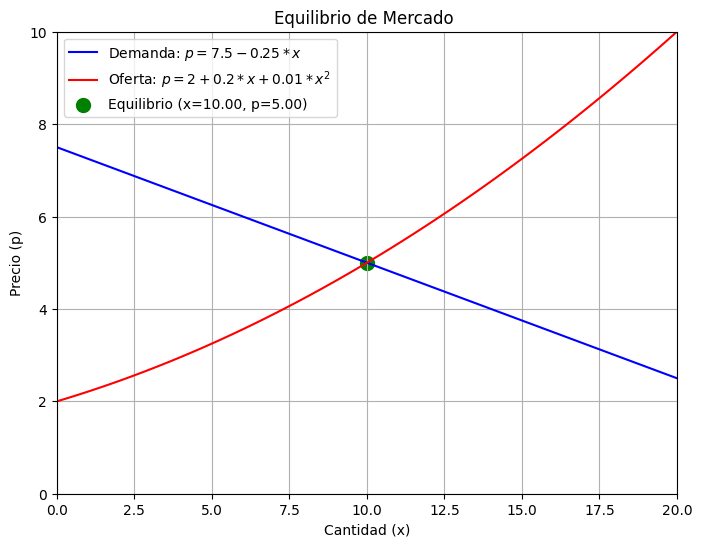

In [ ]:
#Paso 3
# Graficamos

plt.figure(figsize=(8, 6))

#establecemos el rango de x
valores_x = np.linspace(0, 20, 100)

#graficamos las curvas
plt.plot(valores_x, demanda_2(valores_x) , 'blue', label='Demanda: $p = 7.5-0.25*x$')
plt.plot(valores_x, oferta_2(valores_x) , 'red', label='Oferta: $p = 2+0.2 * x +0.01*x^2$')

#Agregamos los detalles del gráfico
plt.scatter(x_eq, p_eq, color='green', s=100, label=f'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})')
plt.ylabel('Precio (p)')
plt.xlabel('Cantidad (x)')
plt.legend()
plt.grid(True)
plt.title('Equilibrio de Mercado ')
plt.xlim(0, 20)
plt.ylim(0, 10)
plt.show()

✅ Ahora supongamos dos situaciones :

a) Se invirtió en publicidad y los consumidores valoran más el producto (con un aumento del intercepto de 1,5)

b) Aparece un producto sustituto más barato (con disminución del intercepto de 1,5)

¿Cómo varía la demanda?¿Qué sucede con el precio de equilibrio?

---




In [ ]:
#Paso 1
#Generamos las nuevas funciones de demanda

def demanda_2_preferencia(x):
  return 9-0.25*x

def demanda_2_sustituto(x):
  return 6-0.25*x

In [ ]:
#Paso 2
#Resolvemos el sistema para hallar los nuevos puntos de equilibrio

# Definimos las variables simbólicas
x, p = sp.symbols('x p')

# Definimos las ecuaciones
eq1 = sp.Eq(p, 7.5-0.25*x)
eq2 = sp.Eq(p, 2+0.2 * x +0.01*x**2)
eq5= sp.Eq(p, 9-0.25*x)
eq6= sp.Eq(p, 6-0.25*x)

# Resolvemos el sistema con mayores preferencias por el producto
solucion_preferencia = sp.solve((eq5, eq2), (x, p))
print(f"Soluciones posibles con mayor preferencia: {solucion_preferencia}")

# Filtramos soluciones con valores positivos
soluciones_validas_pref = [sol for sol in solucion_preferencia if sol[0] > 0 and sol[1] > 0]

if not soluciones_validas_pref:
  print("No se encontraron soluciones económicamente válidas (x > 0, p > 0)")

#Resolvemos el sistema con la entrada del bien sustituto
solucion_sustituto = sp.solve((eq6, eq2), (x, p))
print(f"Soluciones posibles con el bien sustituto: {solucion_sustituto}")

#Filtramos soluciones con valores positivos
soluciones_validas_sustituto = [sol for sol in solucion_sustituto if sol[0] > 0 and sol[1] > 0]

if not soluciones_validas_sustituto:
  print("No se encontraron soluciones Económicas válidas (x > 0, p > 0)")

# Tomamos la solución con valores positivos para ambos casos
x_eq_pref = soluciones_validas_pref[0][0]
p_eq_pref = soluciones_validas_pref[0][1]

x_eq_sustituto = soluciones_validas_sustituto[0][0]
p_eq_sustituto = soluciones_validas_sustituto[0][1]

print(f"Solución: El punto de equilibrio si aumenta la preferencia de los consumidores es, x_eq = {x_eq_pref}, p_eq = {p_eq_pref}")
print(f"Solución: El punto de equilibrio si aparece un bien sustituto es, x_eq = {x_eq_sustituto}, p_eq = {p_eq_sustituto}")

Soluciones posibles con mayor preferencia: [(12.2311099736245, 5.94222250659387), (-57.2311099736245, 23.3077774934061)]
Soluciones posibles con el bien sustituto: [(7.60398644698074, 4.09900338825482), (-52.6039864469807, 19.1509966117452)]
Solución: El punto de equilibrio si aumenta la preferencia de los consumidores es, x_eq = 12.2311099736245, p_eq = 5.94222250659387
Solución: El punto de equilibrio si aparece un bien sustituto es, x_eq = 7.60398644698074, p_eq = 4.09900338825482


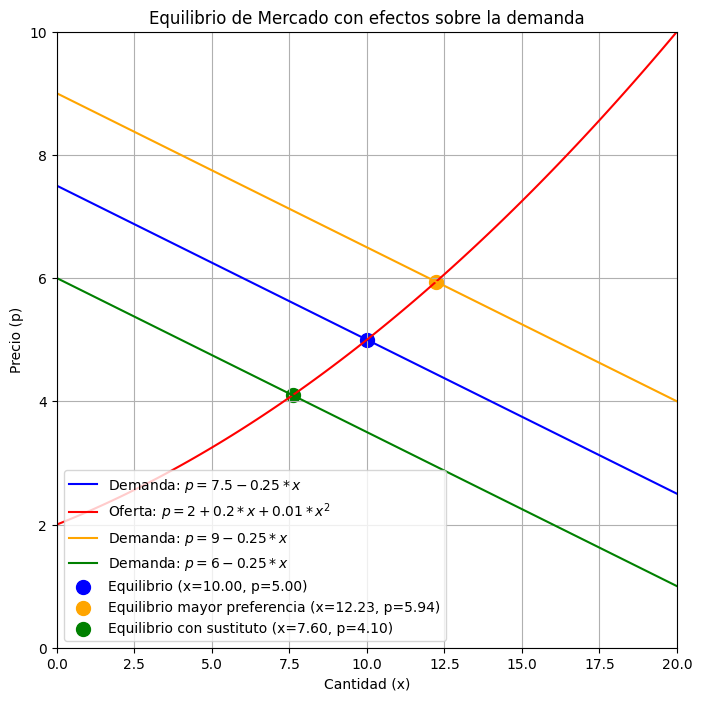

In [ ]:
#Paso 3
# Graficamos con las dos nuevas situaciones

plt.figure(figsize=(8, 8))

#establecemos el rango de x
valores_x = np.linspace(0, 20, 100)

#graficamos las curvas
plt.plot(valores_x, demanda_2(valores_x) , 'blue', label='Demanda: $p = 7.5-0.25*x$')
plt.plot(valores_x, oferta_2(valores_x) , 'red', label='Oferta: $p = 2+0.2 * x +0.01*x^2$')
plt.plot(valores_x, demanda_2_preferencia(valores_x) , 'orange', label='Demanda: $p = 9-0.25*x$')
plt.plot(valores_x, demanda_2_sustituto(valores_x) , 'green', label='Demanda: $p = 6-0.25*x$')

#Agregamos los detalles del gráfico
plt.scatter(x_eq, p_eq, color='blue', s=100, label=f'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})')
plt.scatter(x_eq_pref, p_eq_pref, color='orange', s=100, label=f'Equilibrio mayor preferencia (x={x_eq_pref:.2f}, p={p_eq_pref:.2f})')
plt.scatter(x_eq_sustituto, p_eq_sustituto, color='green', s=100, label=f'Equilibrio con sustituto (x={x_eq_sustituto:.2f}, p={p_eq_sustituto:.2f})')
plt.ylabel('Precio (p)')
plt.xlabel('Cantidad (x)')
plt.legend()
plt.grid(True)
plt.title('Equilibrio de Mercado con efectos sobre la demanda')
plt.xlim(0, 20)
plt.ylim(0, 10)
plt.show()

✅ Un aumento en las preferencias de los consumidores (por ejemplo, debido a una campaña publicitaria exitosa) desplaza la curva de demanda hacia arriba y a la derecha, lo que se traduce en un mayor precio de equilibrio (de 5 a 5.94) y una mayor cantidad transada (de 10 a 12,23 unidades).
Este efecto refleja una mayor disposición a pagar por el producto.

✅ La entrada de bienes sustitutos (como un producto competidor más barato) desplaza la curva de demanda hacia abajo y a la izquierda, reduciendo tanto el precio (de 5 a 4.10) como la cantidad equilibrada (de 10 a 7.6 unidades), ya que los consumidores sustituyen parcialmente el producto original por alternativas más económicas.

✅ Ambos casos ilustran cómo factores externos pueden alterar significativamente el equilibrio de mercado, incluso con una oferta constante.

✅ Estos efectos destacan la importancia de monitorear tanto las preferencias de los consumidores como la competencia en el mercado.



---
⏩ Dado el siguiente sistema:

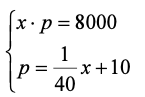

1- Defina las funciones de oferta y demanda

2- Encuentre el punto de equilibrio de mercado

3- Grafique

---




In [ ]:
#Paso 1
#Generamos las funciones

def demanda_3(x):
  return 8000/x

def oferta_3(x):
  return (1/40)*x+10

In [ ]:
#Paso 2
#Resolvemos el sistema para hallar el punto de equilibrio

# Definimos las variables simbólicas
x, p = sp.symbols('x p')

# Definimos las ecuaciones
eq1 = sp.Eq(p, demanda_3(x))
eq2 = sp.Eq(p, oferta_3(x))

# Resolvemos el sistema
solucion = sp.solve((eq1, eq2), (x, p))
print(f"Soluciones posibles: {solucion}")

# Filtramos soluciones con valores positivos
soluciones_validas = [sol for sol in solucion if sol[0] > 0 and sol[1] > 0]

if not soluciones_validas:
  print("No se encontraron soluciones económicamente válidas (x > 0, p > 0)")


# Tomamos la solución con valores positivos
x_eq = soluciones_validas[0][0]
p_eq = soluciones_validas[0][1]

print(f"Solución: El punto de equilibrio es, x_eq = {x_eq}, p_eq = {p_eq}")

Soluciones posibles: [(-800.000000000000, -10.0000000000000), (400.000000000000, 20.0000000000000)]
Solución: El punto de equilibrio es, x_eq = 400.000000000000, p_eq = 20.0000000000000


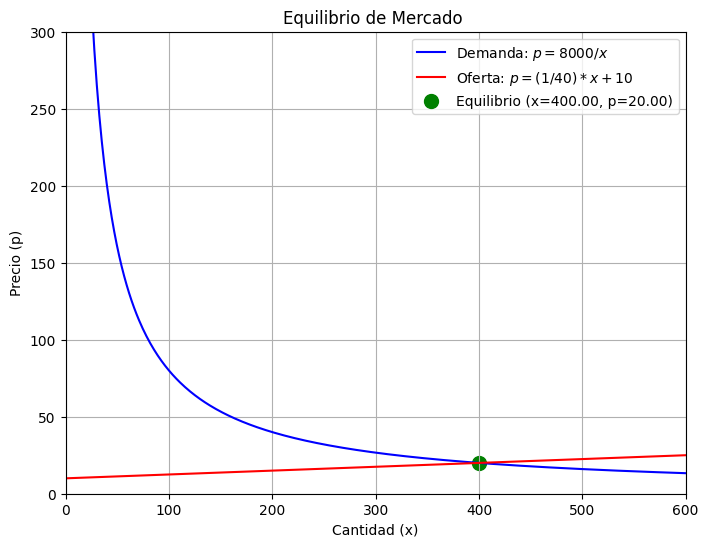

In [ ]:
#Paso 3
# Graficamos

plt.figure(figsize=(8, 6))

#establecemos el rango de x
valores_x = np.linspace(0.1, 600, 500)

#graficamos las curvas
plt.plot(valores_x, demanda_3(valores_x) , 'blue', label='Demanda: $p = 8000/x$')
plt.plot(valores_x, oferta_3(valores_x) , 'red', label='Oferta: $p = (1/40)*x+10$')

#Agregamos los detalles del gráfico
plt.scatter(x_eq, p_eq, color='green', s=100, label=f'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})')
plt.ylabel('Precio (p)')
plt.xlabel('Cantidad (x)')
plt.legend()
plt.grid(True)
plt.title('Equilibrio de Mercado ')

plt.xlim(0, 600)
plt.ylim(0, 300)
plt.show()

✅ Ahora supongamos que se dan dos situaciones simultáneas:

1. Aumento del ingreso de los consumidores que genera un aumento del 20 por ciento de la demanda


2. Aumento de costos variables de producción del 15 por ciento y un aumento del 2 unidades sobre el costo fijo

---




In [ ]:
#Paso 1
#Generamos las nuevas funciones

def demanda_3_aumentada(x):
  return (8000/x)*1.2

def oferta_3_mayor_costo(x):
  return (1/40)*1.15*x+12

In [ ]:
#Paso 2
#Resolvemos el sistema para hallar el nuevo punto de equilibrio

# Definimos las variables simbólicas
x, p = sp.symbols('x p')

# Definimos las ecuaciones
eq7 = sp.Eq(p, demanda_3_aumentada(x))
eq8 = sp.Eq(p, oferta_3_mayor_costo(x))

# Resolvemos el sistema
solucion_nueva = sp.solve((eq7, eq8), (x, p))
print(f"Soluciones nuevas posibles: {solucion_nueva}")

# Filtramos soluciones con valores positivos
soluciones_validas_nuevas = [sol for sol in solucion_nueva if sol[0] > 0 and sol[1] > 0]

if not soluciones_validas_nuevas:
  print("No se encontraron soluciones económicamente válidas (x > 0, p > 0)")


# Tomamos la solución con valores positivos
x_eq_nueva = soluciones_validas_nuevas[0][0]
p_eq_nuevo = soluciones_validas_nuevas[0][1]

print(f"Solución: El punto de equilibrio nueva es, x_eq = {x_eq_nueva}, p_eq = {p_eq_nuevo}")

Soluciones nuevas posibles: [(-823.079016788024, -11.6635217326557), (405.687712440198, 23.6635217326557)]
Solución: El punto de equilibrio nueva es, x_eq = 405.687712440198, p_eq = 23.6635217326557


/tmp/ipykernel_3229069/2183418095.py:5: RuntimeWarning: divide by zero encountered in divide
  return 8000/x


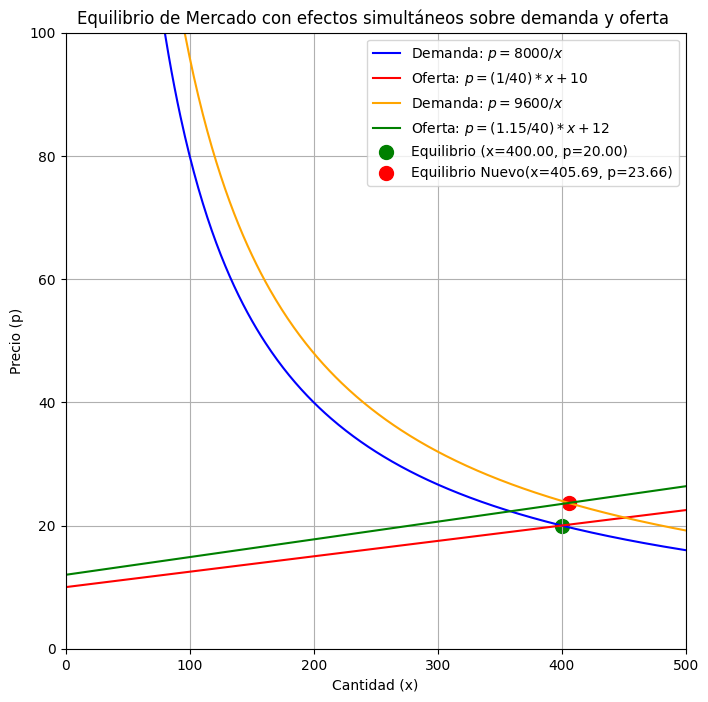

In [ ]:
#Paso 3
# Graficamos

plt.figure(figsize=(8, 8))

#establecemos el rango de x
valores_x = np.linspace(0, 600, 500)

#graficamos las curvas
plt.plot(valores_x, demanda_3(valores_x) , 'blue', label='Demanda: $p = 8000/x$')
plt.plot(valores_x, oferta_3(valores_x) , 'red', label='Oferta: $p = (1/40)*x+10$')
plt.plot(valores_x, demanda_3_aumentada(valores_x) , 'orange', label='Demanda: $p = 9600/x$')
plt.plot(valores_x, oferta_3_mayor_costo(valores_x) , 'green', label='Oferta: $p = (1.15/40)*x+12$')

#Agregamos los detalles del gráfico
plt.scatter(x_eq, p_eq, color='green', s=100, label=f'Equilibrio (x={x_eq:.2f}, p={p_eq:.2f})')
plt.scatter(x_eq_nueva, p_eq_nuevo, color='red', s=100, label=f'Equilibrio Nuevo(x={x_eq_nueva:.2f}, p={p_eq_nuevo:.2f})')

plt.ylabel('Precio (p)')
plt.xlabel('Cantidad (x)')
plt.legend()
plt.grid(True)
plt.title('Equilibrio de Mercado con efectos simultáneos sobre demanda y oferta ')

plt.xlim(0, 500)
plt.ylim(0, 100)
plt.show()

✅ El aumento de demanda (por mejores ingresos) tiende a subir precios y cantidades.

✅ Los mayores costos de producción limitan el aumento de cantidad, concentrando el efecto en precios.

✅ El resultado es un equilibrio con ligero aumento en cantidad (+5,6 unidades) pero impacto significativo en precio (+15%).


✅ Cuando demanda y oferta cambian en direcciones opuestas (↑ demanda + ↓ oferta), el precio siempre aumenta, pero el efecto en cantidad depende de la magnitud relativa de los cambios. En este caso, el aumento de demanda domina levemente sobre la contracción de la oferta.

---

